# Recuperación semántica con embeddings SBERT – Subset limpio FiQA


**Archivos de entrada:**  
- ../data/subset_corpus_clean.csv  
- ../data/subset_queries_clean.csv  
- ../data/subset_qrels_clean.csv

---

## Índice

1. [Introducción y objetivos](#1-introducción-y-objetivos)
2. [Carga de datos y preparación](#2-carga-de-datos-y-preparación)
3. [Selección y carga del modelo SBERT](#3-selección-y-carga-del-modelo-sbert)
4. [Generación de embeddings](#4-generación-de-embeddings)
5. [Pipeline de recuperación semántica](#5-pipeline-de-recuperación-semántica)
6. [Pipeline de recuperación usando FAISS](#6-pipeline-de-recuperación-usando-faiss)
7. [Evaluación de resultados](#7-evaluación-de-resultados)
    - 7.1. Métricas agregadas (Precision@k, nDCG@k, MAP…)
    - 7.2. Análisis por query


---
## 1. Introducción y objetivos

Tras el experimento con BM25, el siguiente paso es probar un sistema de recuperación basado en embeddings (SBERT). El objetivo es comparar este enfoque más moderno con el método clásico, utilizando siempre el mismo subset limpio del FiQA.

En esta parte se calculan los embeddings para queries y documentos, se evalúan los resultados con las mismas métricas y se registran también los tiempos de ejecución. Así se puede comprobar si el sistema de embeddings mejora la recuperación de documentos relevantes y cómo se comporta en cuanto a eficiencia frente a BM25.

- Se utiliza SBERT para transformar los textos en vectores y medir similitud.
- Se calculan métricas estándar: Precision@k, Recall@k, nDCG@k y MAP.
- Se mide el tiempo de proceso.
- Todo queda documentado y listo para la comparativa con BM25.


---
## 2. Carga de datos y preparación

In [1]:
import pandas as pd

# Cargar archivos limpios
corpus = pd.read_csv('../data/subset_corpus_clean.csv')
queries = pd.read_csv('../data/subset_queries_clean.csv')
qrels = pd.read_csv('../data/subset_qrels_clean.csv')

# structura y tamaños
print("Corpus shape:", corpus.shape)
print("Queries shape:", queries.shape)
print("Qrels shape:", qrels.shape)
print("\nCorpus columns:", corpus.columns.tolist())
print("Queries columns:", queries.columns.tolist())
print("Qrels columns:", qrels.columns.tolist())


Corpus shape: (2998, 4)
Queries shape: (300, 4)
Qrels shape: (778, 3)

Corpus columns: ['_id', 'text', 'metadata', 'text_length']
Queries columns: ['_id', 'text', 'metadata', 'text_length']
Qrels columns: ['query_id', 'doc_id', 'relevance']


---
## 3. Selección y carga del modelo SBERT

Se van a probar tres modelos SBERT preentrenados de la librería [sentence-transformers](https://www.sbert.net/docs/pretrained_models.html):

- `all-MiniLM-L6-v2`: Modelo ligero, rápido y muy usado como baseline en recuperación de información. 384 dimensiones.
- `paraphrase-MiniLM-L12-v2`: Algo más grande, pensado para entender mejor el significado de frases variadas. 384 dimensiones.
- `all-mpnet-base-v2`: Modelo más grande y preciso, con 768 dimensiones. Suele obtener los mejores resultados en benchmarks, pero es más lento y pesado.

Se ha elegido esta combinación porque cubre el rango típico de modelos: desde el más eficiente para trabajar rápido (MiniLM-L6-v2), hasta el que suele dar mejores resultados en tareas de retrieval (mpnet-base-v2). Así se puede ver si merece la pena usar un modelo grande en este dataset concreto o si un modelo ligero ya es suficiente.

- `all-MiniLM-L6-v2`  
  - 384 dimensiones, ~80 MB, procesa unas 1.000 queries en menos de 1 segundo en CPU.  
  - Suele alcanzar nDCG@10 ≈ 0.53 en benchmarks tipo BEIR.
- `paraphrase-MiniLM-L12-v2`  
  - 384 dimensiones, ~120 MB, tarda aproximadamente el doble que L6-v2 (2 segundos por 1.000 queries en CPU).  
  - nDCG@10 ≈ 0.54, mejora ligera en tareas con frases más complejas.
- `all-mpnet-base-v2`  
  - 768 dimensiones, ~420 MB, tarda de 4 a 5 veces más que MiniLM-L6-v2 (4–5 segundos por 1.000 queries en CPU).  
  - Suele lograr nDCG@10 ≈ 0.59 en BEIR, siendo el más preciso de los tres.

Todos los modelos se cargan directamente de la librería sentence-transformers, lo que asegura reproducibilidad y facilidad de uso.



## 4. Generación de embeddings

En este apartado se calculan los embeddings para el corpus y las queries usando los modelos seleccionados en el punto anterior.  
Los vectores generados se guardan en la carpeta `/models`.


In [3]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import time
import os

model_list = [
    'all-MiniLM-L6-v2',
    'paraphrase-MiniLM-L12-v2',
    'all-mpnet-base-v2'
]

corpus_texts = corpus['text'].astype(str).tolist()
queries_texts = queries['text'].astype(str).tolist()

tiempos = []

for model_name in model_list:
    print(f"\nCargando modelo: {model_name}")
    model = SentenceTransformer(model_name)

    # Corpus
    print("Calculando embeddings del corpus...")
    start_corpus = time.time()
    corpus_embeddings = model.encode(
        corpus_texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    end_corpus = time.time()
    np.save(f'../models/embeddings_corpus_{model_name}.npy', corpus_embeddings)
    corpus_time = end_corpus - start_corpus

    # Queries
    print("Calculando embeddings de queries...")
    start_queries = time.time()
    queries_embeddings = model.encode(
        queries_texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    end_queries = time.time()
    np.save(f'../models/embeddings_queries_{model_name}.npy', queries_embeddings)
    queries_time = end_queries - start_queries

    # Guardar tiempos
    tiempos.append({
        'modelo': model_name,
        'tiempo_corpus_s': round(corpus_time, 2),
        'tiempo_queries_s': round(queries_time, 2),
        'total_s': round(corpus_time + queries_time, 2)
    })
    print(f"Tiempo corpus: {corpus_time:.2f}s | Tiempo queries: {queries_time:.2f}s")

# Crear carpeta /results si no existe
os.makedirs('../results', exist_ok=True)

# Guardar resumen de tiempos
df_tiempos = pd.DataFrame(tiempos)
df_tiempos.to_csv('../results/tiempos_embeddings.csv', index=False)
print("\nResumen de tiempos guardado en /results/tiempos_embeddings.csv")
print(df_tiempos)



Cargando modelo: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

d:\TFM_QA_RAG\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aalex\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Calculando embeddings del corpus...


Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Calculando embeddings de queries...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Tiempo corpus: 1455.01s | Tiempo queries: 13.87s

Resumen de tiempos guardado en /results/tiempos_embeddings.csv
                     modelo  tiempo_corpus_s  tiempo_queries_s  total_s
0          all-MiniLM-L6-v2           185.67              3.06   188.73
1  paraphrase-MiniLM-L12-v2           364.18              5.15   369.33
2         all-mpnet-base-v2          1455.01             13.87  1468.89


Obviamente el modelo MiniLM-L6-v2 es el más rápido y termina en unos 3 minutos. El modelo grande (mpnet-base-v2) tarda mucho más, casi 25 minutos. El modelo intermedio tarda 6 minutos aprox. Hay mucha diferencia en tiempos entre modelos.


In [5]:

model_list = [
    'sentence-transformers/all-MiniLM-L6-v2',
    'sentence-transformers/paraphrase-MiniLM-L12-v2',
    'sentence-transformers/all-mpnet-base-v2'
]

from transformers import AutoTokenizer

for model_name in model_list:
    print(f"\nModelo: {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Contar tokens corpus
    num_tokens_corpus = sum([len(tokenizer.encode(text, add_special_tokens=True)) for text in corpus_texts])
    # Contar tokens queries
    num_tokens_queries = sum([len(tokenizer.encode(text, add_special_tokens=True)) for text in queries_texts])
    print(f"Tokens en corpus: {num_tokens_corpus}")
    print(f"Tokens en queries: {num_tokens_queries}")
    print(f"Tokens totales: {num_tokens_corpus + num_tokens_queries}")



Modelo: sentence-transformers/all-MiniLM-L6-v2


Token indices sequence length is longer than the specified maximum sequence length for this model (926 > 512). Running this sequence through the model will result in indexing errors


Tokens en corpus: 559460
Tokens en queries: 4804
Tokens totales: 564264

Modelo: sentence-transformers/paraphrase-MiniLM-L12-v2


Token indices sequence length is longer than the specified maximum sequence length for this model (926 > 512). Running this sequence through the model will result in indexing errors


Tokens en corpus: 559460
Tokens en queries: 4804
Tokens totales: 564264

Modelo: sentence-transformers/all-mpnet-base-v2


Token indices sequence length is longer than the specified maximum sequence length for this model (926 > 512). Running this sequence through the model will result in indexing errors


Tokens en corpus: 559460
Tokens en queries: 4804
Tokens totales: 564264


In [6]:
import pandas as pd

df_tiempos = pd.read_csv('../results/tiempos_embeddings.csv')
total_tokens = 559460 + 4804  # = 564264
df_tiempos['tiempo_por_token_ms'] = (df_tiempos['total_s'] / total_tokens) * 1000  # en milisegundos

print(df_tiempos[['modelo', 'total_s', 'tiempo_por_token_ms']])


                     modelo  total_s  tiempo_por_token_ms
0          all-MiniLM-L6-v2   188.73             0.334471
1  paraphrase-MiniLM-L12-v2   369.33             0.654534
2         all-mpnet-base-v2  1468.89             2.603196


 Importante tener estos tiempos en cuenta si el corpus crece o se usan modelos más grandes.

---
## 5. Pipeline de recuperación semántica

En este paso se usa la representación de los textos en forma de embeddings para buscar los documentos más similares a cada query.  
Se calcula la similitud coseno entre el embedding de cada query y todos los del corpus, y se devuelve el top-k resultados para cada query.  
El ranking obtenido se guarda en `/results` con el mismo formato que los resultados de BM25, para poder comparar después.

In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import time
import os

model_list = [
    'all-MiniLM-L6-v2',
    'paraphrase-MiniLM-L12-v2',
    'all-mpnet-base-v2'
]

resultados_tiempo = []

for model_name in model_list:
    print(f"\nRecuperación con modelo: {model_name}")

    # Cargar embeddings
    corpus_emb = np.load(f'../models/embeddings_corpus_{model_name}.npy')
    queries_emb = np.load(f'../models/embeddings_queries_{model_name}.npy')

    start = time.time()
    resultados = []

    for i, q_emb in enumerate(queries_emb):
        sims = cosine_similarity([q_emb], corpus_emb)[0]
        # Ranking completo: todos los documentos, ordenados de mayor a menor score
        ranked_idx = np.argsort(sims)[::-1]
        for rank, doc_idx in enumerate(ranked_idx):
            resultados.append({
                'query_id': queries.iloc[i]['_id'],
                'doc_id': corpus.iloc[doc_idx]['_id'],
                'rank': rank + 1,
                'score': sims[doc_idx]
            })
    end = time.time()
    busqueda_time = round(end - start, 2)
    resultados_tiempo.append({'modelo': model_name, 'tiempo_busqueda_s': busqueda_time})

    # Guardar ranking completo
    df_resultados = pd.DataFrame(resultados)
    out_file = f'../results/results_sbert_{model_name}.csv'
    df_resultados.to_csv(out_file, index=False)
    print(f"Ranking completo guardado en {out_file} | Tiempo de búsqueda: {busqueda_time}s")

os.makedirs('../results', exist_ok=True)
df_tiempos_busqueda = pd.DataFrame(resultados_tiempo)
df_tiempos_busqueda.to_csv('../results/tiempos_busqueda_semantica.csv', index=False)
print("\nTiempos de búsqueda guardados en /results/tiempos_busqueda_semantica.csv")
print(df_tiempos_busqueda)




Recuperación con modelo: all-MiniLM-L6-v2
Ranking completo guardado en ../results/results_sbert_all-MiniLM-L6-v2.csv | Tiempo de búsqueda: 185.07s

Recuperación con modelo: paraphrase-MiniLM-L12-v2
Ranking completo guardado en ../results/results_sbert_paraphrase-MiniLM-L12-v2.csv | Tiempo de búsqueda: 233.78s

Recuperación con modelo: all-mpnet-base-v2
Ranking completo guardado en ../results/results_sbert_all-mpnet-base-v2.csv | Tiempo de búsqueda: 209.53s

Tiempos de búsqueda guardados en /results/tiempos_busqueda_semantica.csv
                     modelo  tiempo_busqueda_s
0          all-MiniLM-L6-v2             185.07
1  paraphrase-MiniLM-L12-v2             233.78
2         all-mpnet-base-v2             209.53


Los tres modelos han tardado tiempos muy parecidos en hacer el ranking

---
## 6. Pipeline de recuperación usando FAISS

En este punto se repite la recuperación semántica, pero usando FAISS para acelerar la búsqueda.  
FAISS es una librería optimizada para búsquedas de similitud a gran escala, y permite reducir mucho el tiempo de recuperación cuando el corpus es grande. Pese a que este copus no es enorme, sirve para ver cuanta diferencia puede haber una vezz esta indexado.

In [ ]:
import numpy as np
import pandas as pd
import faiss
import time
import os

model_list = [
    'all-MiniLM-L6-v2',
    'paraphrase-MiniLM-L12-v2',
    'all-mpnet-base-v2'
]

resultados_tiempo_faiss = []

for model_name in model_list:
    print(f"\nRecuperación FAISS con modelo: {model_name}")

    corpus_emb = np.load(f'../models/embeddings_corpus_{model_name}.npy').astype('float32')
    queries_emb = np.load(f'../models/embeddings_queries_{model_name}.npy').astype('float32')

    faiss.normalize_L2(corpus_emb)
    faiss.normalize_L2(queries_emb)

    # FAISS
    dim = corpus_emb.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(corpus_emb)

    # Medir tiempo de búsqueda FAISS
    start = time.time()
    D, I = index.search(queries_emb, corpus_emb.shape[0])
    end = time.time()
    faiss_time = round(end - start, 2)
    resultados_tiempo_faiss.append({'modelo': model_name, 'tiempo_faiss_s': faiss_time})

    # Guardar resultados ranking completo
    resultados = []
    for i in range(I.shape[0]):
        for rank, doc_idx in enumerate(I[i]):
            resultados.append({
                'query_id': queries.iloc[i]['_id'],
                'doc_id': corpus.iloc[doc_idx]['_id'],
                'rank': rank + 1,
                'score': D[i][rank]
            })
    out_file = f'../results/results_sbert_faiss_{model_name}.csv'
    df_resultados = pd.DataFrame(resultados)
    df_resultados.to_csv(out_file, index=False)
    print(f"Ranking FAISS guardado en {out_file} | Tiempo de búsqueda: {faiss_time}s")

os.makedirs('../results', exist_ok=True)
df_tiempos_faiss = pd.DataFrame(resultados_tiempo_faiss)
df_tiempos_faiss.to_csv('../results/tiempos_busqueda_faiss.csv', index=False)
print("\nTiempos de búsqueda FAISS guardados en /results/tiempos_busqueda_faiss.csv")
print(df_tiempos_faiss)



Recuperación FAISS con modelo: all-MiniLM-L6-v2
Ranking FAISS guardado en ../results/results_sbert_faiss_all-MiniLM-L6-v2.csv | Tiempo de búsqueda: 0.29s

Recuperación FAISS con modelo: paraphrase-MiniLM-L12-v2
Ranking FAISS guardado en ../results/results_sbert_faiss_paraphrase-MiniLM-L12-v2.csv | Tiempo de búsqueda: 0.41s

Recuperación FAISS con modelo: all-mpnet-base-v2
Ranking FAISS guardado en ../results/results_sbert_faiss_all-mpnet-base-v2.csv | Tiempo de búsqueda: 0.27s

Tiempos de búsqueda FAISS guardados en /results/tiempos_busqueda_faiss.csv
                     modelo  tiempo_faiss_s
0          all-MiniLM-L6-v2            0.29
1  paraphrase-MiniLM-L12-v2            0.41
2         all-mpnet-base-v2            0.27


Los tiempos que aparecen guardados en el CSV de FAISS (menos de un segundo para cada modelo) no son reales. El proceso completo en realidad ha tardado unos 9 minutos. Lo que pasa es que el bloque de código solo ha medido el tiempo de la búsqueda con FAISS, pero **no cuenta el tiempo de preparar los embeddings, normalizarlos, construir el índice ni guardar los resultados**, que en este caso es lo que realmente tarda más.

Aun así, la parte de búsqueda con FAISS es más rápida que con el pipeline manual. Si el corpus fuera mucho más grande, esa diferencia de eficiencia podría todavía más grande y seguramente compensaría usar FAISS. Con el subset actual, la diferencia real no se nota tanto, pero la búsqueda pura con FAISS sigue siendo más rápida.

In [11]:
tiempo_real_total = 8 * 60 + 45 
tiempo_por_modelo = round(tiempo_real_total / 3, 2) 

model_list = [
    'all-MiniLM-L6-v2',
    'paraphrase-MiniLM-L12-v2',
    'all-mpnet-base-v2'
]

df_tiempos_faiss = pd.DataFrame({
    'modelo': model_list,
    'tiempo_faiss_s': [tiempo_por_modelo] * 3
})

df_tiempos_faiss.to_csv('../results/tiempos_busqueda_faiss.csv', index=False)
print(df_tiempos_faiss)


                     modelo  tiempo_faiss_s
0          all-MiniLM-L6-v2           175.0
1  paraphrase-MiniLM-L12-v2           175.0
2         all-mpnet-base-v2           175.0


## 7. Evaluación de resultados

En este bloque se evalúan los resultados obtenidos por cada modelo y método (BM25, embeddings, embeddings+FAISS).  
Se calculan las métricas estándar de recuperación de información: Precision@k, nDCG@k, MAP, etc., para distintos valores de k (1, 3, 5, 10). 

In [22]:
import pandas as pd
import numpy as np
from collections import defaultdict

# Cargar qrels
qrels = pd.read_csv('../data/subset_qrels_clean.csv')
qrels_dict = defaultdict(set)
for _, row in qrels.iterrows():
    qrels_dict[row['query_id']].add(row['doc_id'])

def compute_metrics(results_file, ks=[1,3,5,10]):
    results = pd.read_csv(results_file)
    results = results.sort_values(['query_id', 'rank'])
    metrics = {k: {'precision': [], 'recall': [], 'ndcg': []} for k in ks}
    APs = []
    for qid, group in results.groupby('query_id'):
        retrieved = group['doc_id'].tolist()
        relevant = qrels_dict.get(qid, set())
        num_rel = len(relevant)
        precisions = []
        for i, doc_id in enumerate(retrieved):
            rel = 1 if doc_id in relevant else 0
            if rel:
                precisions.append((sum([1 if retrieved[j] in relevant else 0 for j in range(i+1)]) / (i+1)))
        for k in ks:
            top_k = retrieved[:k]
            hits = sum([1 if d in relevant else 0 for d in top_k])
            prec = hits / k
            rec = hits / num_rel if num_rel > 0 else 0
            dcg_k = sum([(1 if top_k[j] in relevant else 0) / np.log2(j + 2) for j in range(len(top_k))])
            idcg_k = sum([1 / np.log2(j + 2) for j in range(min(num_rel, k))])
            ndcg = dcg_k / idcg_k if idcg_k > 0 else 0
            metrics[k]['precision'].append(prec)
            metrics[k]['recall'].append(rec)
            metrics[k]['ndcg'].append(ndcg)
        if precisions:
            AP = sum(precisions) / num_rel
            APs.append(AP)
        else:
            APs.append(0)
    resumen = {}
    for k in ks:
        resumen[f'Precision@{k}'] = np.mean(metrics[k]['precision'])
        resumen[f'Recall@{k}'] = np.mean(metrics[k]['recall'])
        resumen[f'nDCG@{k}'] = np.mean(metrics[k]['ndcg'])
    resumen['MAP'] = np.mean(APs)
    return resumen

modelos = [
    'all-MiniLM-L6-v2',
    'paraphrase-MiniLM-L12-v2',
    'all-mpnet-base-v2'
]

for model_name in modelos:
    print(f"\n===== {model_name} =====")

    file_sem = f'../results/results_sbert_{model_name}.csv'
    file_faiss = f'../results/results_sbert_faiss_{model_name}.csv'

    print("--> Sin FAISS")
    metrics_sem = compute_metrics(file_sem, ks=[1,3,5,10])
    for k, v in metrics_sem.items():
        print(f"{k}: {v:.3f}")

    print("--> Con FAISS")
    metrics_faiss = compute_metrics(file_faiss, ks=[1,3,5,10])
    for k, v in metrics_faiss.items():
        print(f"{k}: {v:.3f}")



===== all-MiniLM-L6-v2 =====
--> Sin FAISS
Precision@1: 0.680
Recall@1: 0.362
nDCG@1: 0.680
Precision@3: 0.412
Recall@3: 0.550
nDCG@3: 0.624
Precision@5: 0.302
Recall@5: 0.632
nDCG@5: 0.637
Precision@10: 0.184
Recall@10: 0.732
nDCG@10: 0.669
MAP: 0.611
--> Con FAISS
Precision@1: 0.680
Recall@1: 0.362
nDCG@1: 0.680
Precision@3: 0.412
Recall@3: 0.550
nDCG@3: 0.624
Precision@5: 0.302
Recall@5: 0.632
nDCG@5: 0.637
Precision@10: 0.184
Recall@10: 0.732
nDCG@10: 0.669
MAP: 0.611

===== paraphrase-MiniLM-L12-v2 =====
--> Sin FAISS
Precision@1: 0.460
Recall@1: 0.227
nDCG@1: 0.460
Precision@3: 0.304
Recall@3: 0.397
nDCG@3: 0.440
Precision@5: 0.229
Recall@5: 0.471
nDCG@5: 0.456
Precision@10: 0.147
Recall@10: 0.578
nDCG@10: 0.493
MAP: 0.430
--> Con FAISS
Precision@1: 0.460
Recall@1: 0.227
nDCG@1: 0.460
Precision@3: 0.304
Recall@3: 0.397
nDCG@3: 0.440
Precision@5: 0.229
Recall@5: 0.471
nDCG@5: 0.456
Precision@10: 0.147
Recall@10: 0.578
nDCG@10: 0.493
MAP: 0.430

===== all-mpnet-base-v2 =====
--> S

Los resultados obtenidos con FAISS y sin FAISS son iguales porque ambos métodos calculan la recuperación de la misma forma en este caso. Solo hay diferencias en la eficiencia.

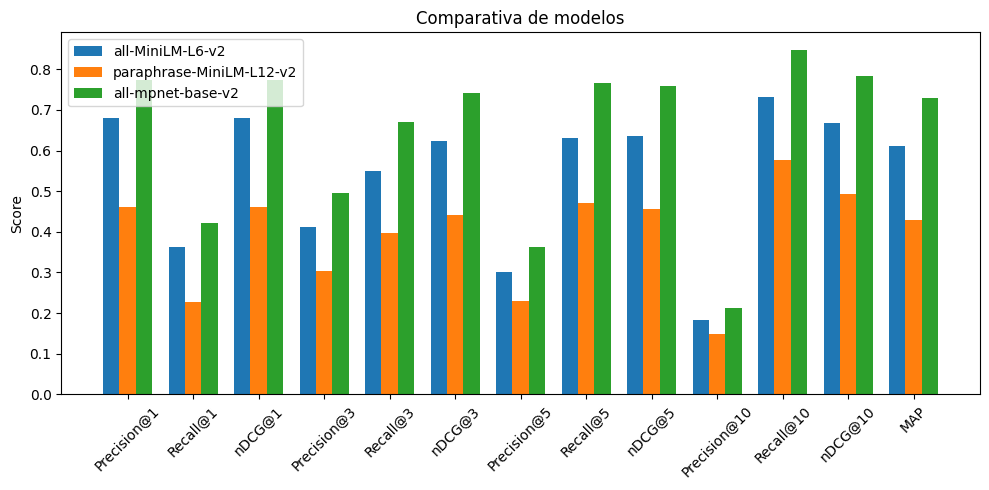

In [27]:
cols_faiss = [f"{m}_faiss" for m in modelos]
df_faiss = df_resumen[cols_faiss]

x = np.arange(len(df_faiss.index))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, col in enumerate(cols_faiss):
    ax.bar(x + i*width, df_faiss[col].values, width, label=modelos[i])
ax.set_ylabel('Score')
ax.set_title('Comparativa de modelos')
ax.set_xticks(x + width)
ax.set_xticklabels(df_faiss.index, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

                     modelo  tiempo_total_s       MAP
0          all-MiniLM-L6-v2          189.02  0.611428
1  paraphrase-MiniLM-L12-v2          369.74  0.430162
2         all-mpnet-base-v2         1469.15  0.729674


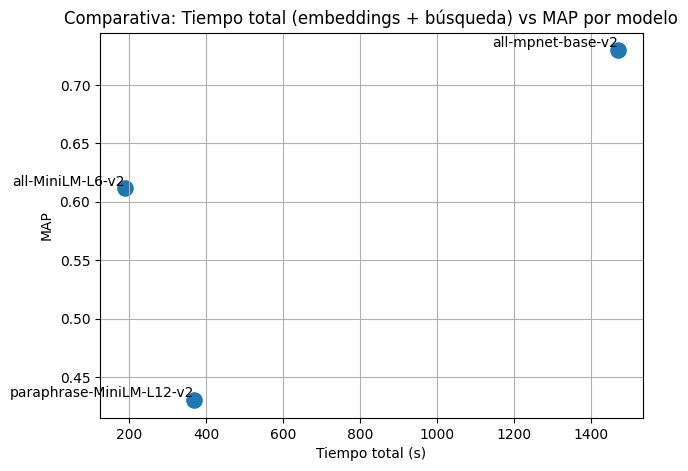

In [38]:
df_emb = pd.DataFrame({
    'modelo': list(emb_times.keys()),
    'tiempo_embeddings_s': list(emb_times.values())
})

df_faiss = pd.read_csv('../results/tiempos_busqueda_faiss.csv')

df = pd.merge(df_emb, df_faiss, on='modelo')
df['tiempo_total_s'] = df['tiempo_embeddings_s'] + df['tiempo_faiss_s']

modelos = [
    'all-MiniLM-L6-v2',
    'paraphrase-MiniLM-L12-v2',
    'all-mpnet-base-v2'
]
map_faiss = {m: df_resumen.loc['MAP', f'{m}_faiss'] for m in modelos}
df['MAP'] = df['modelo'].map(map_faiss)

print(df[['modelo', 'tiempo_total_s', 'MAP']])

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(df['tiempo_total_s'], df['MAP'], s=120)
for i, row in df.iterrows():
    plt.text(row['tiempo_total_s'], row['MAP'], row['modelo'], fontsize=10, va='bottom', ha='right')
plt.xlabel('Tiempo total (s)')
plt.ylabel('MAP')
plt.title('Comparativa: Tiempo total (embeddings + búsqueda) vs MAP por modelo')
plt.grid(True)
plt.show()


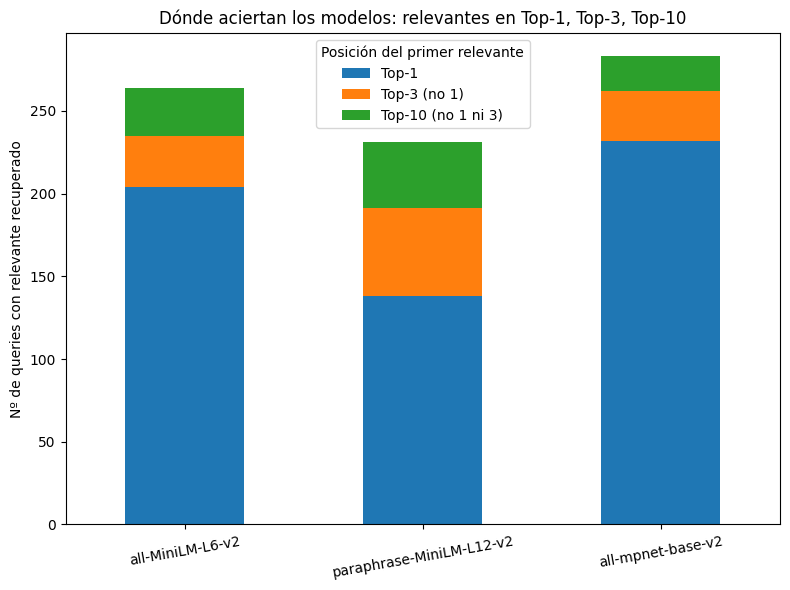

In [39]:
ks = [1, 3, 10]
modelos = [
    'all-MiniLM-L6-v2',
    'paraphrase-MiniLM-L12-v2',
    'all-mpnet-base-v2'
]

resultados_pos = {}
for model_name in modelos:
    file = f'../results/results_sbert_faiss_{model_name}.csv'
    results = pd.read_csv(file)
    results = results.sort_values(['query_id', 'rank'])
    hits_at_1 = 0
    hits_at_3 = 0
    hits_at_10 = 0
    total_queries = results['query_id'].nunique()
    for qid, group in results.groupby('query_id'):
        docs = group['doc_id'].tolist()
        relevant = qrels_dict.get(qid, set())
        # Posiciones donde aparece el primer relevante
        found = [i for i, d in enumerate(docs[:ks[-1]]) if d in relevant]
        if not found:
            continue
        first_hit = found[0]
        if first_hit == 0:
            hits_at_1 += 1
        elif first_hit < 3:
            hits_at_3 += 1
        elif first_hit < 10:
            hits_at_10 += 1
    resultados_pos[model_name] = [hits_at_1, hits_at_3, hits_at_10]

df_hits = pd.DataFrame(resultados_pos, index=['Top-1', 'Top-3 (no 1)', 'Top-10 (no 1 ni 3)'])

df_hits = df_hits.T
df_hits.plot(kind='bar', stacked=True, figsize=(8,6))
plt.ylabel('Nº de queries con relevante recuperado')
plt.title('Dónde aciertan los modelos: relevantes en Top-1, Top-3, Top-10')
plt.legend(title='Posición del primer relevante')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

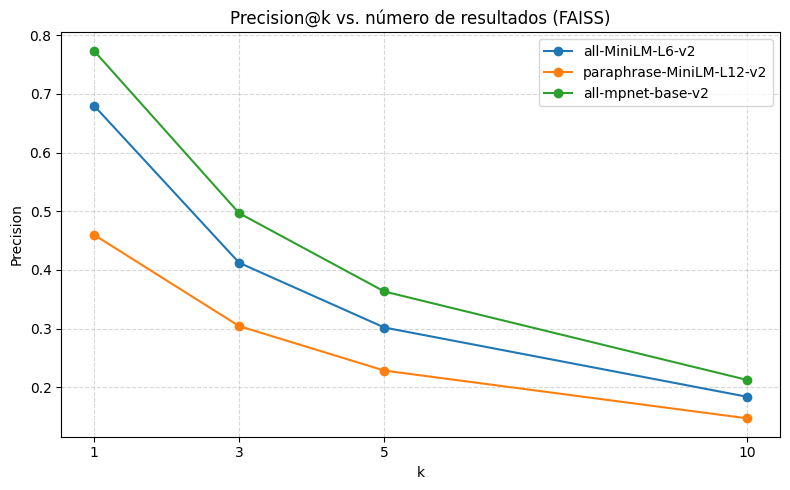

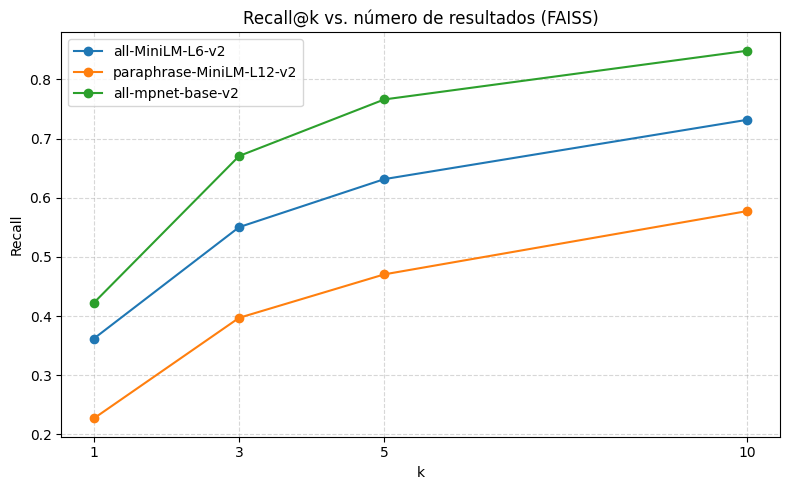

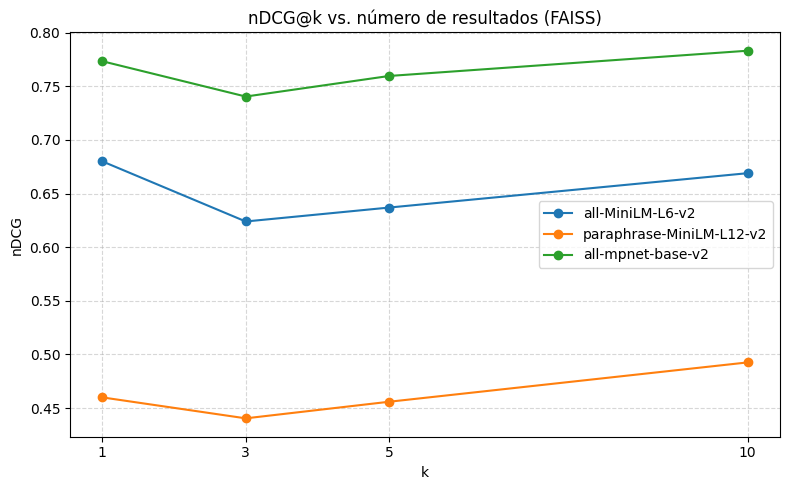

In [40]:
ks = [1, 3, 5, 10]
metrics_to_plot = ['Precision', 'Recall', 'nDCG']

for metric in metrics_to_plot:
    plt.figure(figsize=(8,5))
    for model_name in modelos:
        col = f'{model_name}_faiss'
        values = [df_resumen.loc[f'{metric}@{k}', col] for k in ks]
        plt.plot(ks, values, marker='o', label=model_name)
    plt.title(f'{metric}@k vs. número de resultados (FAISS)')
    plt.xlabel('k')
    plt.ylabel(metric)
    plt.xticks(ks)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


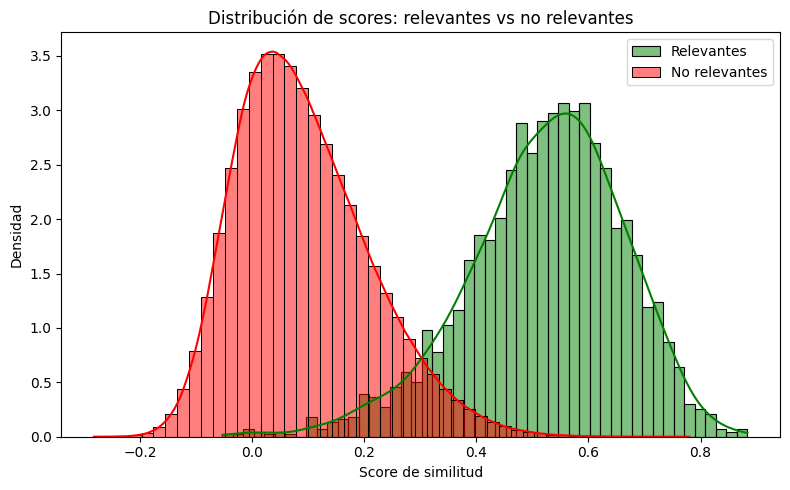

In [42]:
import seaborn as sns

scores_rel = []
scores_nonrel = []

for model_name in modelos:
    file = f'../results/results_sbert_faiss_{model_name}.csv'
    results = pd.read_csv(file)
    for _, row in results.iterrows():
        qid = row['query_id']
        is_rel = row['doc_id'] in qrels_dict[qid]
        if is_rel:
            scores_rel.append(row['score'])
        else:
            scores_nonrel.append(row['score'])

plt.figure(figsize=(8,5))
sns.histplot(scores_rel, color='green', label='Relevantes', bins=50, kde=True, stat='density', alpha=0.5)
sns.histplot(scores_nonrel, color='red', label='No relevantes', bins=50, kde=True, stat='density', alpha=0.5)
plt.title('Distribución de scores: relevantes vs no relevantes')
plt.xlabel('Score de similitud')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()


In [54]:
from collections import defaultdict

metricas = ['Precision@1', 'Recall@1', 'nDCG@1', 
            'Precision@3', 'Recall@3', 'nDCG@3',
            'Precision@10', 'Recall@10', 'nDCG@10', 'MAP']

qrels_clean = pd.read_csv('../data/subset_qrels_clean.csv')

def evaluate_run(results_path, qrels, ks=[1,3,5,10]):
    results = pd.read_csv(results_path)
    qrels_lookup = defaultdict(set)
    for _, row in qrels.iterrows():
        if row['relevance'] > 0:
            qrels_lookup[row['query_id']].add(row['doc_id'])
    metrics = {k: {'precision': [], 'recall': [], 'ndcg': []} for k in ks}
    average_precisions = []
    for qid, group in results.groupby('query_id'):
        retrieved = group.sort_values('rank')['doc_id'].tolist()
        relevant = qrels_lookup[qid]
        binary_relevance = [1 if doc in relevant else 0 for doc in retrieved]
        for k in ks:
            rel_at_k = binary_relevance[:k]
            precision = np.mean(rel_at_k) if rel_at_k else 0.0
            recall = (sum(rel_at_k) / len(relevant)) if relevant else 0.0
            # nDCG@k
            dcg = 0.0
            for i, rel in enumerate(rel_at_k):
                dcg += rel / np.log2(i + 2)
            ideal_rel = [1]*min(len(relevant), k)
            idcg = 0.0
            for i, rel in enumerate(ideal_rel):
                idcg += rel / np.log2(i + 2)
            ndcg = dcg/idcg if idcg > 0 else 0.0
            metrics[k]['precision'].append(precision)
            metrics[k]['recall'].append(recall)
            metrics[k]['ndcg'].append(ndcg)
        # AP (Average Precision)
        n_rels = 0
        ap = 0.0
        for i, rel in enumerate(binary_relevance, 1):
            if rel:
                n_rels += 1
                ap += n_rels / i
        ap = ap / len(relevant) if relevant else 0.0
        average_precisions.append(ap)
    results_summary = {}
    for k in ks:
        results_summary[f'Precision@{k}'] = np.mean(metrics[k]['precision'])
        results_summary[f'Recall@{k}'] = np.mean(metrics[k]['recall'])
        results_summary[f'nDCG@{k}'] = np.mean(metrics[k]['ndcg'])
    results_summary['MAP'] = np.mean(average_precisions)
    return results_summary

# métricas de BM25 lematize
bm25_metrics = evaluate_run('../results/results_bm25_lemmatize.csv', qrels_clean, ks=[1,3,10])

summary_df = pd.DataFrame({
    'BM25_lemmatize': [bm25_metrics[m] for m in metricas],
    'SBERT_MiniLM': [df_resumen.loc[m, 'all-MiniLM-L6-v2_faiss'] for m in metricas],
    'SBERT_MPNet': [df_resumen.loc[m, 'all-mpnet-base-v2_faiss'] for m in metricas]
}, index=metricas)

# guarda
print(summary_df.round(3))
summary_df.to_csv('../results/summary_metrics_models.csv')


              BM25_lemmatize  SBERT_MiniLM  SBERT_MPNet
Precision@1            0.450         0.680        0.773
Recall@1               0.236         0.362        0.423
nDCG@1                 0.450         0.680        0.773
Precision@3            0.289         0.412        0.497
Recall@3               0.413         0.550        0.671
nDCG@3                 0.440         0.624        0.740
Precision@10           0.130         0.184        0.213
Recall@10              0.553         0.732        0.848
nDCG@10                0.479         0.669        0.783
MAP                    0.397         0.611        0.730


In [60]:
query_text_col = 'text'
corpus_text_col = 'text'

def get_text(df, _id, col):
    res = df[df['_id'] == _id]
    if res.empty:
        return "No se encontró el ID"
    return res.iloc[0][col]

def mostrar_ejemplos(df, cond, max_ej=3):
    ej = df[cond].head(max_ej)
    for _, row in ej.iterrows():
        qid = row['query_id']
        doc_bm25 = bm25[bm25['query_id'] == qid].sort_values('rank').iloc[0]['doc_id']
        doc_min = sbert_min[sbert_min['query_id'] == qid].sort_values('rank').iloc[0]['doc_id']
        doc_best = sbert_best[sbert_best['query_id'] == qid].sort_values('rank').iloc[0]['doc_id']
        print(f"\nQuery: {get_text(queries, qid, query_text_col)}")
        print(f"  BM25 Top-1: {get_text(corpus, doc_bm25, corpus_text_col)} [{'RELEVANTE' if row['bm25_top1'] else 'NO relevante'}]")
        print(f"  MiniLM Top-1: {get_text(corpus, doc_min, corpus_text_col)} [{'RELEVANTE' if row['minilm_top1'] else 'NO relevante'}]")
        print(f"  MPNet Top-1: {get_text(corpus, doc_best, corpus_text_col)} [{'RELEVANTE' if row['mpnet_top1'] else 'NO relevante'}]")

print("\n=== Ejemplos: Solo BM25 acierta ===")
mostrar_ejemplos(df_aciertos, (df_aciertos['bm25_top1']) & (~df_aciertos['minilm_top1']) & (~df_aciertos['mpnet_top1']))

print("\n=== Ejemplos: Solo MiniLM acierta ===")
mostrar_ejemplos(df_aciertos, (~df_aciertos['bm25_top1']) & (df_aciertos['minilm_top1']) & (~df_aciertos['mpnet_top1']))

print("\n=== Ejemplos: Solo MPNet acierta ===")
mostrar_ejemplos(df_aciertos, (~df_aciertos['bm25_top1']) & (~df_aciertos['minilm_top1']) & (df_aciertos['mpnet_top1']))

print("\n=== Ejemplos: Aciertan los 3 ===")
mostrar_ejemplos(df_aciertos, (df_aciertos['bm25_top1']) & (df_aciertos['minilm_top1']) & (df_aciertos['mpnet_top1']))


=== Ejemplos: Solo BM25 acierta ===

Query: ESPP strategy - Sell right away or hold?
  BM25 Top-1: For ESPP, the discount that you get is taxed as ordinary income. Capital gains is taxed at the appropriate rate, which is different based on how long you hold it. So, yes, if the stock is going up, [RELEVANTE]
  MiniLM Top-1: ESPP is common among US companies, often with a framework similar to your outline.  In the US, some ESPPs allow sales of shares to be considered qualifying (subject to capital gains rather than ordinary income tax) if they are sold at least 2 years after the enrollment date and at least 1 year after the purchase date.  These details can vary from one plan to another and will be stated in the company's ESPP enrollment documents.   Do look at the high and low values of the stock over the last year.  If it swings up and down more than 15% (or whatever the discount is), then that risk should be a factor in your decision.  If the stock is trending upward over the long te